In [68]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
random.seed(20)
np.random.seed(10)

In [69]:
def calculateErrorSurface(X, y):
    """
    Generate data points for plotting the error surface.
    X: design matrix
    y: labels (y = a1*x1 + a2*x2)
    A1, A2: meshgrid of the attributes
    J: MSE surface
    """
    # Get the number of examples.
    N = len(y)

    # Generate values for parameters.
    M = 200
    a1 = np.linspace(-12.0, 14.0, M)
    a2 = np.linspace(-12.0, 14.0, M)
    # Generate the mesh grid.
    A1, A2 = np.meshgrid(a1, a2)

    # Get the attributes
    x1 = X[:,0].reshape(N, 1)
    x2 = X[:,1].reshape(N, 1)

    # Generate points for plotting the cost-function surface.
    J = np.zeros((M,M))
    for iter1 in range(0, M):
        for iter2 in range(0, M):
            # Hypothesis function.
            yhat = A1[iter1, iter2]*x1 + A2[iter1, iter2]*x2
            # Calculate the MSE.
            J[iter1, iter2] = (1.0/N)*np.sum(np.square(y - yhat))

    return J, A1, A2

### Exercício 7


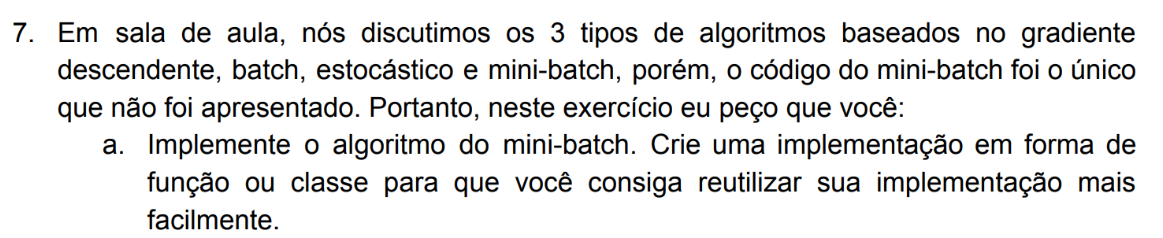

*Gradiente Descendente em mini-lotes*

In [70]:
def gradient_descent_minibatch(X,y,epochs,N,mb,alpha):
    """
    X: training examples
    y: training labels (y_noisy/funcao observavel)
    epochs: number of epochs
    N: number of examples
    mb: minibatch size
    alpha: learning rate/step size
    """
    m = X.shape[1] #number of attributes
    
    #a = np.ones(m).reshape(2,1) # initial column vector of weights
    a = np.array([[10],[-10]])

    a_hist = np.zeros((epochs*int(N/mb)+1,m)) # matrix that stores the weight history
    a_hist[0,:] = a.reshape(1,m)

    mse_hist = np.zeros((epochs*int(N/mb)+1)) # matrix that stores the error history
    mse_hist[0] = (1/N) * np.sum((y- (X @ a))**2)
    it = 0
    
    for e in range(epochs):
        shuffled_indexes = random.sample(range(0, N), N) # Shuffling the whole dataset before every epoch.
        for i in range(0,N,mb):
            # Randomly selecting mb training examples
            random_indexes = tuple(shuffled_indexes[i:i+mb])
            xi = X[random_indexes,:]
            yi = y[random_indexes,:]

            yi_hat = xi @ a                      # funcao hipotese
            grad = (-2 * ((yi-yi_hat).T @ xi)).T # column vector of the gradient of the mse function
            a = a - alpha * (1/mb) * grad        # weight update

            # Saving the histories
            a_hist[it,:] = a.reshape(1,m)
            mse_hist[it] = (1/N) * np.sum((yi-yi_hat)**2)
            it+=1

    
    return a, a_hist, mse_hist


*Gradiente Descendente Estocástico*

(Como o GDML é uma generalização, para a questão 7e, poderia-se apenas chamar a função `gradient_descent_minibatch`. Porém, vou deixar as demais implementações registradas)

In [71]:
def stochastic_gradient_descent(X,y,epochs,N,alpha):
    """
    X: training examples
    y: training labels (y_noisy/funcao observavel)
    epochs: number of epochs
    N: number of examples
    alpha: learning rate/step size
    """
    m = X.shape[1] #number of attributes
    
    #a = np.ones(m).reshape(2,1) # initial column vector of weights
    a = np.array([[10],[-10]])

    a_hist = np.zeros((epochs*N+1,m)) # matrix that stores the weight history
    a_hist[0,:] = a.reshape(1,m)

    mse_hist = np.zeros((epochs*N+1)) # matrix that stores the error history
    mse_hist[0] = (1/N) * np.sum((y- (X @ a))**2)
    it=0
    
    for e in range(epochs):
        shuffled_indexes = random.sample(range(0, N), N) # Shuffling the whole dataset before every epoch.
        for i in range(0,N):
            # Randomly selecting 1 training example 
            random_index = shuffled_indexes[i]
            xi = X[random_index,:].reshape(m,1)
            yi = y[random_index,:].reshape(1,1)

            yi_hat = a.T @ xi                      # funcao hipotese
            grad = (-2 * (xi @ (yi-yi_hat) ))    # column vector of the gradient of the mse function
            a = a - alpha * grad                 # weight update

            # Saving the histories
            a_hist[it,:] = a.reshape(1,m)
            mse_hist[it] = (1/N) * np.sum((yi-yi_hat)**2)
            it+=1

    return a, a_hist, mse_hist

*Gradiente Descendente em Batelada*

In [72]:
def batch_gradient_descent(X,y,epochs,N,alpha):
    """
    X: training examples
    y: training labels (y_noisy/funcao observavel)
    epochs: number of epochs
    N: number of examples
    alpha: learning rate/step size
    """
    m = X.shape[1] #number of attributes
    
    #a = np.ones(m).reshape(2,1) # initial column vector of weights
    a = np.array([[10],[-10]])

    a_hist = np.zeros((epochs*N+1,m)) # matrix that stores the weight history
    a_hist[0,:] = a.reshape(1,m)

    mse_hist = np.zeros((epochs*N+1)) # matrix that stores the error history
    mse_hist[0] = (1/N) * np.sum((y- (X @ a))**2)
    
    
    # HERE, ONE EPOCH IS EQUAL TO ONE ITERATION
    for e in range(epochs):
        y_hat = X @ a                      # funcao hipotese
        grad = (-2 * ((y-y_hat).T @ X)).T # column vector of the gradient of the mse function
        a = a - alpha * grad        # weight update

        # Saving the histories
        a_hist[e,:] = a.reshape(1,m)
        mse_hist[e] = (1/N) * np.sum((y-y_hat)**2)

    return a, a_hist, mse_hist

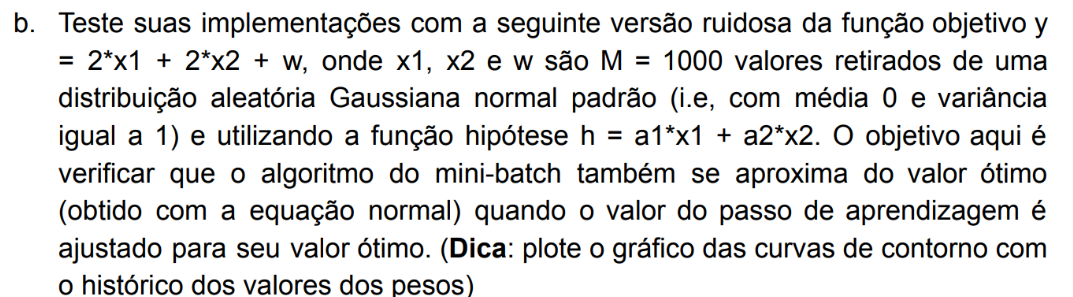

In [73]:
m = 1000
x1 = np.random.randn(m).reshape(m,1)
x2 = np.random.randn(m).reshape(m,1)
w = np.random.randn(m).reshape(m,1)

y_obj = 2*x1 + 1*x2
y_noisy = y_obj + w
X = np.c_[x1,x2]

Encontrando o ponto de mínimo com a equação normal

In [74]:
a_opt = np.linalg.inv(X.T @ X) @ X.T @ y_noisy
h_opt = X @ a_opt
print(a_opt)
#print(h_opt)

[[1.99708072]
 [0.93386595]]


Encontrando o ponto de mínimo com o GDML

In [75]:
epochs = 100
mini_batch_size = 10
alpha = 0.001
a, a_hist, mse_hist = gradient_descent_minibatch(X,y_noisy,epochs,m,mini_batch_size,alpha)
h = X @ a
print(a)
#print(h)

[[1.99723599]
 [0.93344143]]


Plotando a superfície de erro

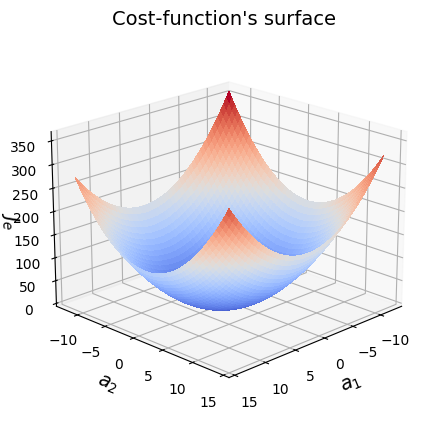

In [76]:
J, A1, A2 = calculateErrorSurface(X, y_noisy)

# Plot cost-function surface.
fig = plt.figure(figsize=(5,5))
plt.subplot(projection='3d')
ax = fig.gca()
surf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14);
plt.title('Cost-function\'s surface', fontsize=14)
ax.view_init(20, 45)
ax.zaxis.labelpad=-3
#Show the plot.
plt.show()

Plotando a superfície de contorno com o histórico dos pesos

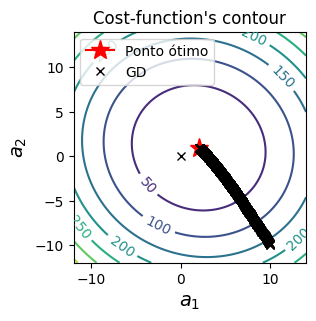

In [77]:
J,A1,A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(a_hist[:, 0], a_hist[:, 1], 'kx', label='GD')

#plt.xticks(np.arange(-12, 14, step=2.0))
#plt.yticks(np.arange(-12, 14, step=2.0))

plt.legend()
plt.show()


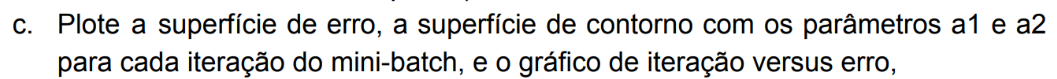

[1.28885521 0.66708439 1.91982988 ... 0.01114797 0.00505026 0.        ]


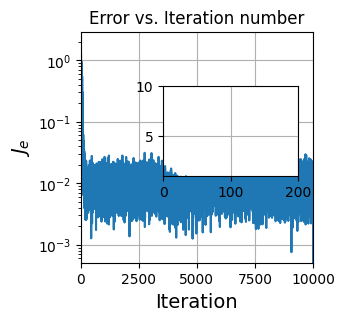

In [85]:
fig = plt.figure(figsize=(3,3))

plt.plot(np.arange(0, len(mse_hist)), mse_hist[:])
plt.xlim((0, len(mse_hist)))
plt.yscale('log')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('$J_e$', fontsize=14)
plt.title('Error vs. Iteration number')
plt.grid()

left, bottom, width, height = [0.4, 0.4, 0.45, 0.3]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(np.arange(0, len(mse_hist)), mse_hist[:])
ax1.set_xlim(0, 200)
ax1.set_ylim(1, 10)
ax1.grid()

print(mse_hist)
plt.show()

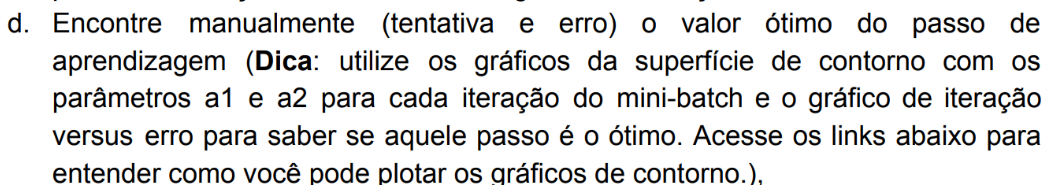

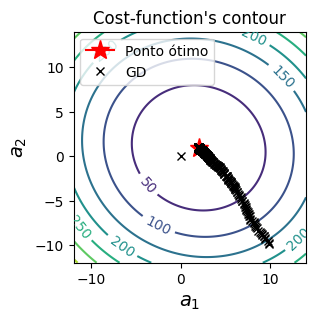

In [79]:
alpha_test = 0.01
a, a_hist, mse_hist = gradient_descent_minibatch(X,y_noisy,epochs,m,mini_batch_size,alpha_test)
h = X @ a

J,A1,A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(a_hist[:, 0], a_hist[:, 1], 'kx', label='GD')

#plt.xticks(np.arange(-12, 14, step=2.0))
#plt.yticks(np.arange(-12, 14, step=2.0))

plt.legend()
plt.show()

alpha = 1 -> diverge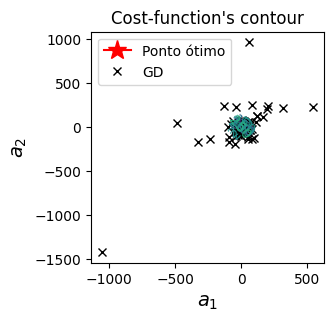 

alpha = 0.1 -> converge rapidamente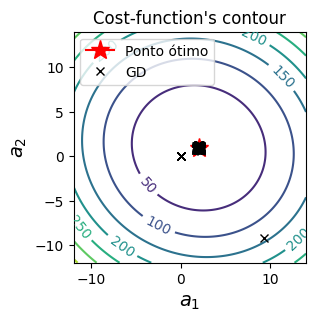

alpha = 0.001 -> converge lentamente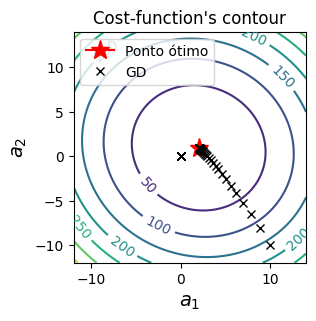

alpha = 0.0001 -> não chega a convergir pra esse numero de iterações e épocas![alt text](image.png)

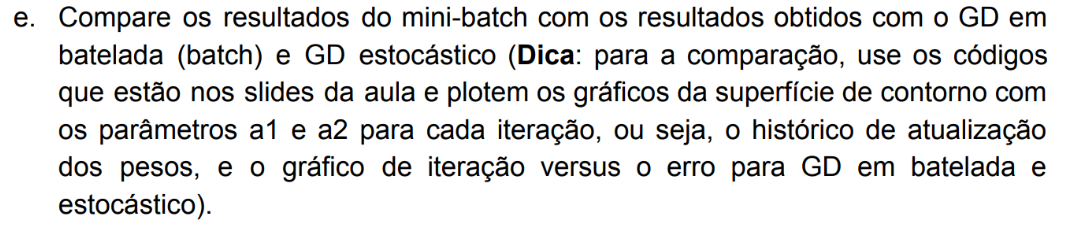

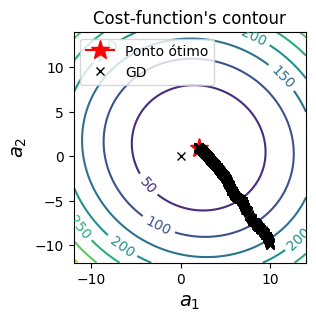

In [80]:
a_s, a_hist_s, mse_hist_s = stochastic_gradient_descent(X,y_noisy,epochs,m,0.001)
J,A1,A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(a_hist_s[:, 0], a_hist_s[:, 1], 'kx', label='GD')

plt.legend()
plt.show()

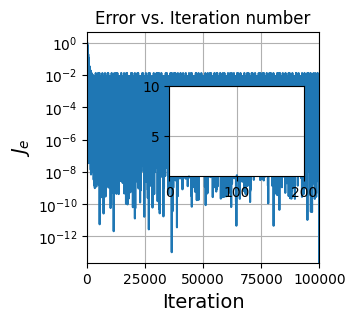

In [87]:
fig = plt.figure(figsize=(3,3))

plt.plot(np.arange(0, len(mse_hist_s)), mse_hist_s[:])
plt.xlim((0, len(mse_hist_s)))
plt.yscale('log')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('$J_e$', fontsize=14)
plt.title('Error vs. Iteration number')
plt.grid()

left, bottom, width, height = [0.4, 0.4, 0.45, 0.3]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(np.arange(0, len(mse_hist_s)), mse_hist_s[:])
ax1.set_xlim(0, 200)
ax1.set_ylim(1, 10)
ax1.grid()

#plt.savefig("error_vs_iteration_sgd.png", dpi=600)
plt.show()

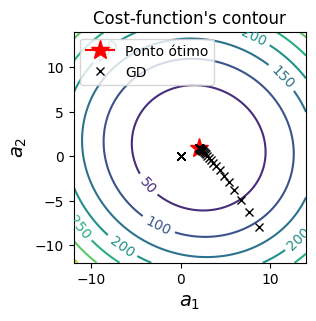

In [82]:
a_b, a_hist_b, mse_hist_b = batch_gradient_descent(X,y_noisy,epochs,m,0.0001)
J,A1,A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(a_hist_b[:, 0], a_hist_b[:, 1], 'kx', label='GD')

#plt.xticks(np.arange(-12, 14, step=2.0))
#plt.yticks(np.arange(-12, 14, step=2.0))

plt.legend()
plt.show()

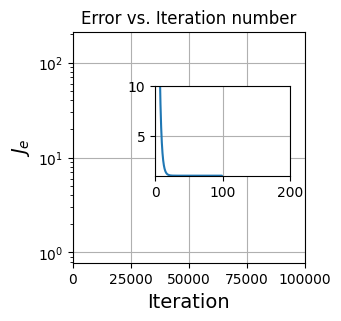

In [83]:
fig = plt.figure(figsize=(3,3))

plt.plot(np.arange(0, len(mse_hist_b)), mse_hist_b[:])
plt.xlim((0, len(mse_hist_b)))
plt.yscale('log')
plt.xlabel('Iteration', fontsize=14)
plt.ylabel('$J_e$', fontsize=14)
plt.title('Error vs. Iteration number')
plt.grid()

left, bottom, width, height = [0.4, 0.4, 0.45, 0.3]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.plot(np.arange(0, len(mse_hist_b)), mse_hist_b[:])
ax1.set_xlim(0, 200)
ax1.set_ylim(1, 10)
ax1.grid()

#plt.savefig("error_vs_iteration_sgd.png", dpi=600)
plt.show()